<a href="https://colab.research.google.com/github/sreejit-19/IQF/blob/main/SREEJIT_FINAL_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving Sorted_Asset_Pricing_Data.csv to Sorted_Asset_Pricing_Data.csv
User uploaded file "Sorted_Asset_Pricing_Data.csv" with length 694185 bytes


  PRINCIPAL COMPONENT LOADINGS
             PC1     PC2     PC3
SMB       0.6375  0.0391 -0.1971
HML       0.6635  0.1677 -0.0206
WML      -0.2653 -0.4213 -0.4629
Size      0.1094 -0.4073  0.7673
BM       -0.1410  0.5825 -0.1260
Momentum  0.2261 -0.5364 -0.3767

Variance explained:
  PC1: 30.69%
  PC2: 20.10%
  PC3: 16.09%
  Total (3 PCs): 66.87%

────────────────────────────────────────────────────────────
  ECONOMIC INTERPRETATION
────────────────────────────────────────────────────────────
PC1  =  +0.66·HML  +0.64·SMB  −0.27·WML
PC2  =  +0.58·BM  −0.54·Momentum  −0.42·WML  −0.41·Size
PC3  =  +0.77·Size  −0.46·WML  −0.38·Momentum

  MODEL PERFORMANCE SUMMARY (mean across all stocks)
        CAPM_Adj_R2  Multi_Adj_R2  PCA_Adj_R2
mean         0.2085        0.2972      0.2938
median       0.2030        0.3072      0.2912
std          0.1136        0.1318      0.1299



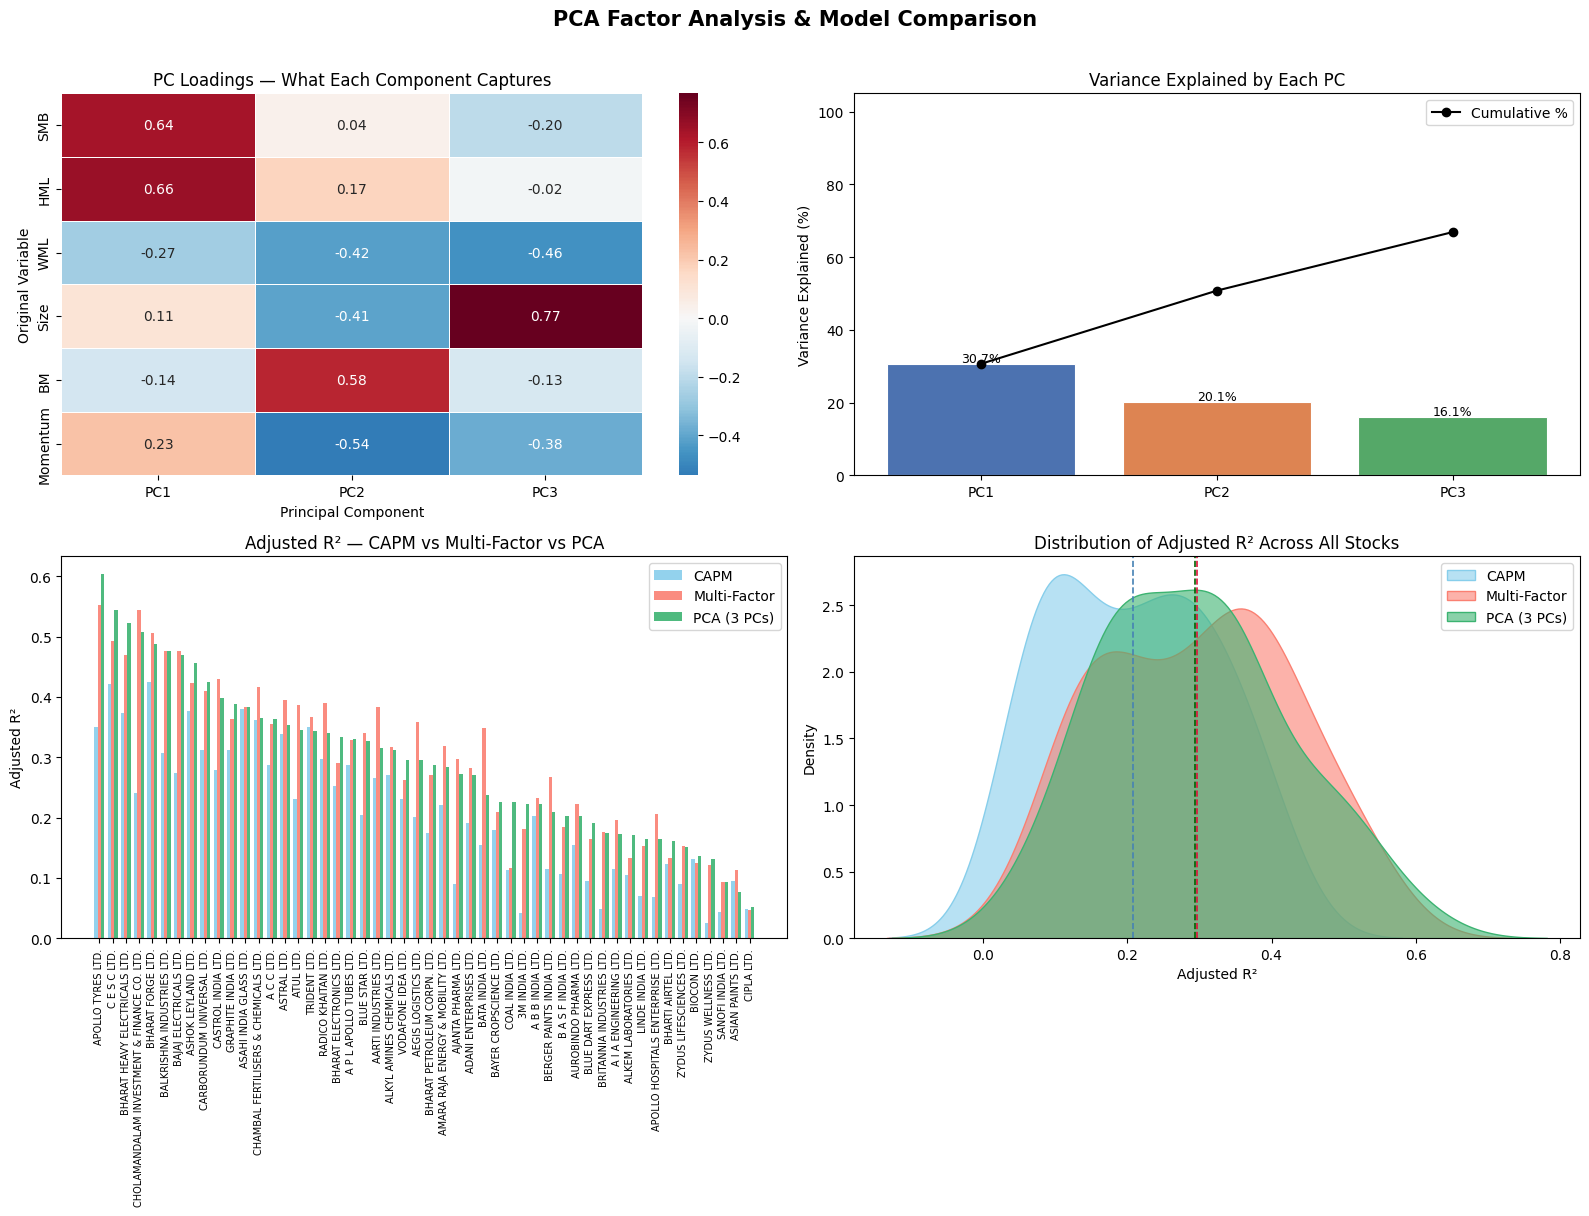

In [ ]:
#PCA - in factor
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────
# 1. LOAD & PREPARE DATA
# ─────────────────────────────────────────────
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y']      = df['Stock_Return']  - RF
df['Mkt_RF'] = df['Market_Return'] - RF

# Features used for PCA (the "characteristic" variables)
pca_features = ['SMB', 'HML', 'WML', 'Size', 'BM', 'Momentum']

# ─────────────────────────────────────────────
# 2. RUN PCA  (standardise first — mandatory)
# ─────────────────────────────────────────────
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(df[pca_features])

pca        = PCA(n_components=3)
pc_scores  = pca.fit_transform(X_scaled)          # shape: (n_obs, 3)

df['PC1']  = pc_scores[:, 0]
df['PC2']  = pc_scores[:, 1]
df['PC3']  = pc_scores[:, 2]

# ─────────────────────────────────────────────
# 3. INTERPRET EACH PRINCIPAL COMPONENT
#    Loadings = correlations of original vars with each PC
# ─────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_.T,                 # shape: (n_features, n_components)
    index   = pca_features,
    columns = ['PC1', 'PC2', 'PC3']
)

print("=" * 60)
print("  PRINCIPAL COMPONENT LOADINGS")
print("=" * 60)
print(loadings.round(4))
print()

explained = pca.explained_variance_ratio_
print("Variance explained:")
for i, v in enumerate(explained, 1):
    print(f"  PC{i}: {v:.2%}")
print(f"  Total (3 PCs): {explained.sum():.2%}")
print()

# Human-readable interpretation of each PC
def interpret_pc(pc_name, loadings_col, threshold=0.25):
    """Print the dominant contributors to a PC."""
    dominant = loadings_col[loadings_col.abs() >= threshold].sort_values(key=abs, ascending=False)
    terms = []
    for var, loading in dominant.items():
        sign = "+" if loading > 0 else "−"
        terms.append(f"{sign}{abs(loading):.2f}·{var}")
    formula = "  ".join(terms)
    print(f"{pc_name}  =  {formula}")

print("─" * 60)
print("  ECONOMIC INTERPRETATION")
print("─" * 60)
for pc in ['PC1', 'PC2', 'PC3']:
    interpret_pc(pc, loadings[pc])
print()

# ─────────────────────────────────────────────
# 4. REGRESSION LOOP — three models per stock
# ─────────────────────────────────────────────
stocks  = df['Co_Name'].unique()
results = []

for stock in stocks:
    s = df[df['Co_Name'] == stock].copy()

    # CAPM
    capm = sm.OLS(s['Y'], sm.add_constant(s['Mkt_RF'])).fit()

    # Multi-Factor (Fama-French + Momentum)
    mf = sm.OLS(
        s['Y'],
        sm.add_constant(s[['Mkt_RF', 'SMB', 'HML', 'WML']])
    ).fit()

    # PCA Model  (market + first 3 PCs)
    pca_model = sm.OLS(
        s['Y'],
        sm.add_constant(s[['Mkt_RF', 'PC1', 'PC2', 'PC3']])
    ).fit()

    results.append({
        'Stock'         : stock,
        'CAPM_Adj_R2'   : capm.rsquared_adj,
        'Multi_Adj_R2'  : mf.rsquared_adj,
        'PCA_Adj_R2'    : pca_model.rsquared_adj,
        'CAPM_AIC'      : capm.aic,
        'Multi_AIC'     : mf.aic,
        'PCA_AIC'       : pca_model.aic,
    })

res = pd.DataFrame(results)

# ─────────────────────────────────────────────
# 5.  SUMMARY TABLE
# ─────────────────────────────────────────────
print("=" * 60)
print("  MODEL PERFORMANCE SUMMARY (mean across all stocks)")
print("=" * 60)
summary = res[['CAPM_Adj_R2','Multi_Adj_R2','PCA_Adj_R2']].agg(['mean','median','std'])
print(summary.round(4))
print()

# ─────────────────────────────────────────────
# 6.  PLOT 1 — Loadings heatmap (what are the PCs?)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PCA Factor Analysis & Model Comparison', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0, 0]
sns.heatmap(
    loadings,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdBu_r',
    center   = 0,
    linewidths = 0.5,
    ax       = ax
)
ax.set_title('PC Loadings — What Each Component Captures')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Original Variable')

# ─────────────────────────────────────────────
# 7.  PLOT 2 — Scree / variance explained
# ─────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(['PC1', 'PC2', 'PC3'], explained * 100,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=0.8)
ax.plot(['PC1', 'PC2', 'PC3'], np.cumsum(explained) * 100,
        marker='o', color='black', linewidth=1.5, label='Cumulative %')
for bar, val in zip(bars, explained * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)
ax.set_title('Variance Explained by Each PC')
ax.set_ylabel('Variance Explained (%)')
ax.set_ylim(0, 105)
ax.legend()

# ─────────────────────────────────────────────
# 8.  PLOT 3 — Adj R² bar chart (all 3 models, sorted by PCA)
# ─────────────────────────────────────────────
ax   = axes[1, 0]
r_s  = res.sort_values('PCA_Adj_R2', ascending=False)
x    = np.arange(len(r_s))
w    = 0.25

ax.bar(x - w,   r_s['CAPM_Adj_R2'],  w, label='CAPM',         color='skyblue',  alpha=0.9)
ax.bar(x,       r_s['Multi_Adj_R2'], w, label='Multi-Factor',  color='salmon',   alpha=0.9)
ax.bar(x + w,   r_s['PCA_Adj_R2'],   w, label='PCA (3 PCs)',   color='mediumseagreen', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(r_s['Stock'], rotation=90, fontsize=7)
ax.set_title('Adjusted R² — CAPM vs Multi-Factor vs PCA')
ax.set_ylabel('Adjusted R²')
ax.legend()

# ─────────────────────────────────────────────
# 9.  PLOT 4 — KDE distribution comparison
# ─────────────────────────────────────────────
ax = axes[1, 1]
sns.kdeplot(res['CAPM_Adj_R2'],  fill=True, label='CAPM',        color='skyblue',        ax=ax, alpha=0.6)
sns.kdeplot(res['Multi_Adj_R2'], fill=True, label='Multi-Factor', color='salmon',         ax=ax, alpha=0.6)
sns.kdeplot(res['PCA_Adj_R2'],   fill=True, label='PCA (3 PCs)',  color='mediumseagreen', ax=ax, alpha=0.6)

# Mark means with vertical lines
for col, color in zip(['CAPM_Adj_R2','Multi_Adj_R2','PCA_Adj_R2'],
                      ['steelblue','crimson','darkgreen']):
    ax.axvline(res[col].mean(), color=color, linestyle='--', linewidth=1.2)

ax.set_title('Distribution of Adjusted R² Across All Stocks')
ax.set_xlabel('Adjusted R²')
ax.legend()

plt.tight_layout()
plt.savefig('pca_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Training rows : 3000  (2018.0–2022.0)
Test rows     : 600   (2023.0–2023.0)

PC Loadings:
             PC1    PC2    PC3
SMB       0.635  0.066 -0.258
HML       0.658  0.211 -0.063
WML      -0.238 -0.429 -0.577
Size      0.137 -0.357  0.717
BM       -0.168  0.568 -0.165
Momentum  0.246 -0.563 -0.235 

Variance explained: ['30.80%', '20.35%', '16.16%']

  MODEL PERFORMANCE — MEAN ACROSS ALL STOCKS
               CAPM   Multi     PCA
Metric                             
InSample_R2  0.2146  0.3064  0.2940
OOS_R2       0.0365  0.0373  0.0286
RMSE         0.0780  0.0775  0.0771
MAE          0.0608  0.0612  0.0614

─────────────────────────────────────────────────────────────────
  WINNER PER METRIC
─────────────────────────────────────────────────────────────────
  InSample_R2        → Multi  {'CAPM': np.float64(0.21457658697091297), 'Multi': np.float64(0.3063647769307854), 'PCA': np.float64(0.29402287050000936)}
  OOS_R2             → Multi  {'CAPM': np.float64(0.03647126769832067), 'Multi

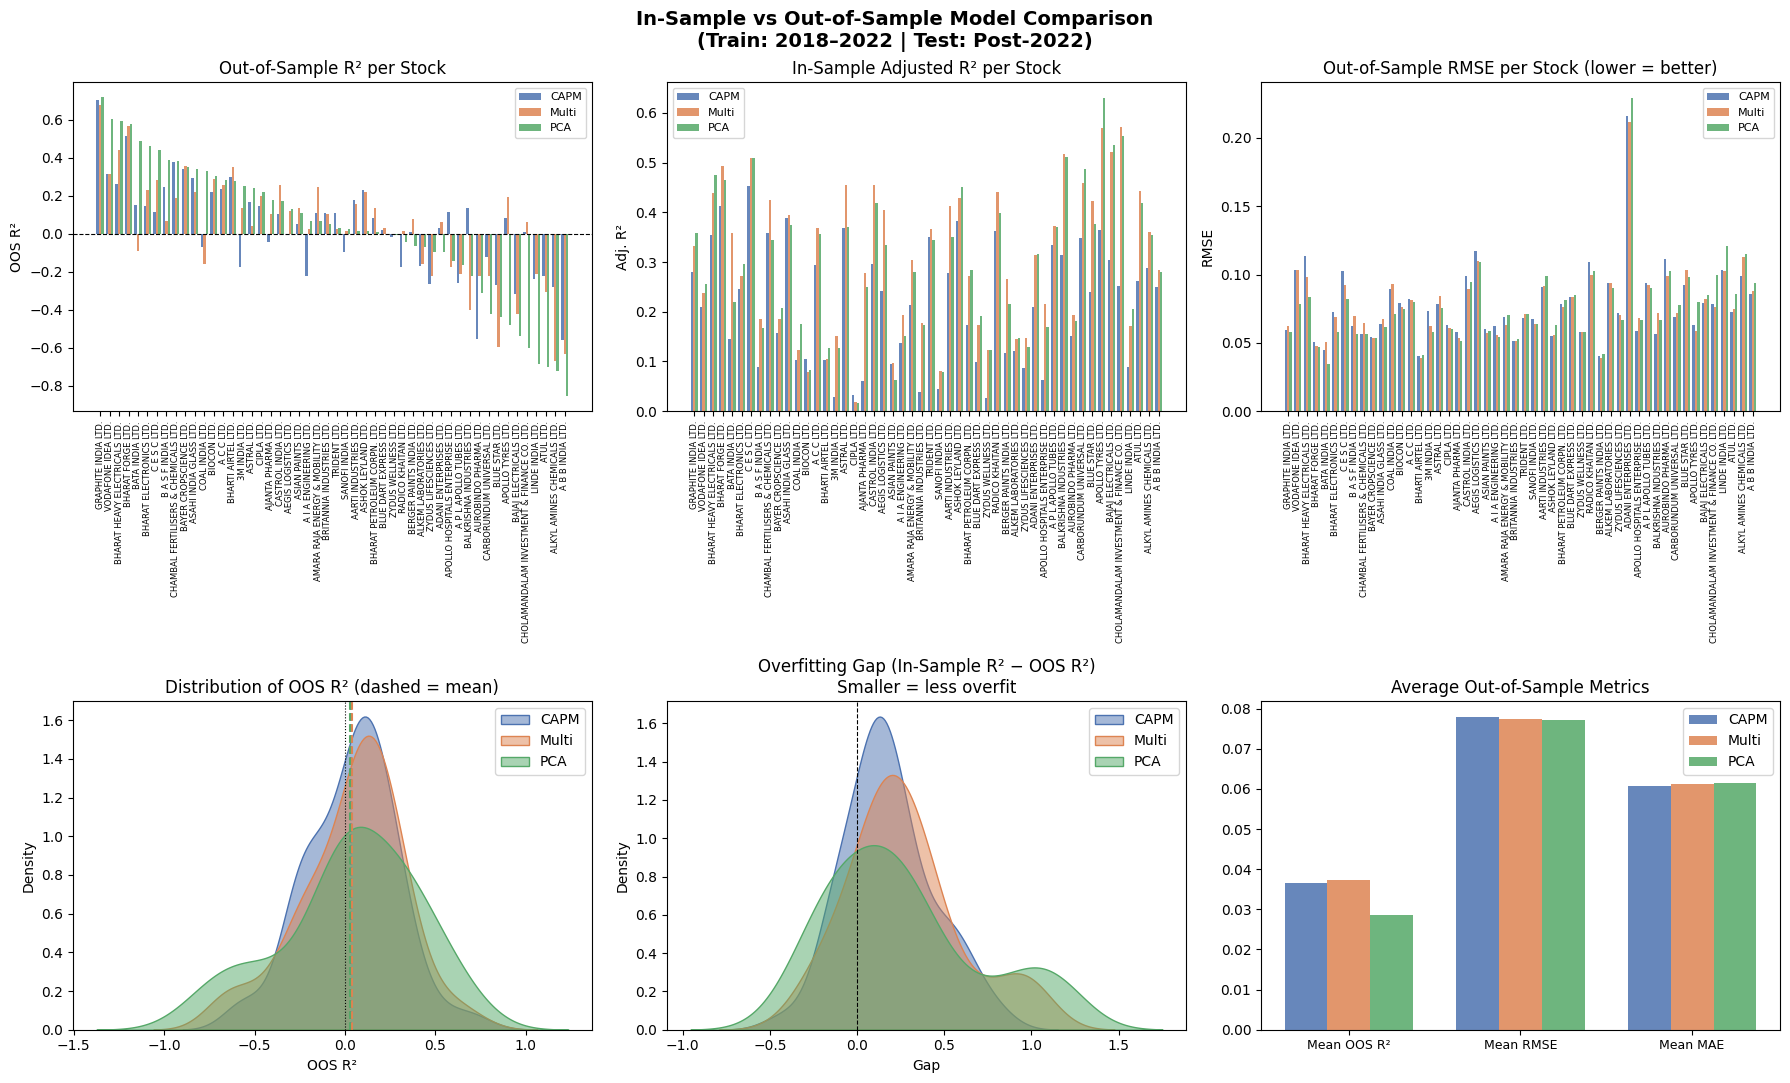

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ─────────────────────────────────────────────
# 1. LOAD & PREPARE DATA
# ─────────────────────────────────────────────
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y']      = df['Stock_Return']  - RF
df['Mkt_RF'] = df['Market_Return'] - RF

pca_features = ['SMB', 'HML', 'WML', 'Size', 'BM', 'Momentum']

# ─────────────────────────────────────────────
# 2. TRAIN / TEST SPLIT BY YEAR
# ─────────────────────────────────────────────
train_df = df[df['Year'].between(2018, 2022)].copy()
test_df  = df[df['Year'] > 2022].copy()

print(f"Training rows : {len(train_df)}  ({train_df['Year'].min()}–{train_df['Year'].max()})")
print(f"Test rows     : {len(test_df)}   ({test_df['Year'].min()}–{test_df['Year'].max()})")
print()

# ─────────────────────────────────────────────
# 3. FIT PCA ON TRAINING DATA ONLY
#    (never let test data touch the scaler/PCA)
# ─────────────────────────────────────────────
scaler    = StandardScaler()
X_train   = scaler.fit_transform(train_df[pca_features])
X_test    = scaler.transform(test_df[pca_features])      # same scaler, transform only

pca       = PCA(n_components=3)
pca.fit(X_train)

train_df[['PC1','PC2','PC3']] = pca.transform(X_train)
test_df[['PC1','PC2','PC3']]  = pca.transform(X_test)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index   = pca_features,
    columns = ['PC1','PC2','PC3']
)
print("PC Loadings:\n", loadings.round(3), "\n")
print("Variance explained:", [f"{v:.2%}" for v in pca.explained_variance_ratio_])
print()

# ─────────────────────────────────────────────
# 4. PER-STOCK REGRESSION + OUT-OF-SAMPLE EVAL
# ─────────────────────────────────────────────
stocks  = train_df['Co_Name'].unique()
results = []

for stock in stocks:
    tr = train_df[train_df['Co_Name'] == stock]
    te = test_df[test_df['Co_Name']   == stock]

    if len(te) == 0:          # stock absent in test period — skip
        continue

    y_test = te['Y'].values

    models = {
        'CAPM'  : (sm.OLS(tr['Y'], sm.add_constant(tr['Mkt_RF'])).fit(),
                   sm.add_constant(te['Mkt_RF'])),
        'Multi' : (sm.OLS(tr['Y'], sm.add_constant(tr[['Mkt_RF','SMB','HML','WML']])).fit(),
                   sm.add_constant(te[['Mkt_RF','SMB','HML','WML']])),
        'PCA'   : (sm.OLS(tr['Y'], sm.add_constant(tr[['Mkt_RF','PC1','PC2','PC3']])).fit(),
                   sm.add_constant(te[['Mkt_RF','PC1','PC2','PC3']])),
    }

    row = {'Stock': stock}
    for name, (fitted, X_te) in models.items():
        y_pred = fitted.predict(X_te)

        # In-sample
        row[f'{name}_InSample_R2']  = fitted.rsquared_adj

        # Out-of-sample metrics
        ss_res = np.sum((y_test - y_pred) ** 2)
        ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        oos_r2 = 1 - ss_res / ss_tot          # can be negative (worse than mean)

        row[f'{name}_OOS_R2']   = oos_r2
        row[f'{name}_RMSE']     = np.sqrt(mean_squared_error(y_test, y_pred))
        row[f'{name}_MAE']      = np.mean(np.abs(y_test - y_pred))

    results.append(row)

res = pd.DataFrame(results)

# ─────────────────────────────────────────────
# 5. AGGREGATE SUMMARY
# ─────────────────────────────────────────────
metrics = ['InSample_R2','OOS_R2','RMSE','MAE']
models  = ['CAPM','Multi','PCA']

print("=" * 65)
print("  MODEL PERFORMANCE — MEAN ACROSS ALL STOCKS")
print("=" * 65)
rows = []
for metric in metrics:
    row = {'Metric': metric}
    for m in models:
        col = f'{m}_{metric}'
        row[m] = res[col].mean().round(4)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Metric')
print(summary.to_string())
print()

# Winner per metric
print("─" * 65)
print("  WINNER PER METRIC")
print("─" * 65)
for metric in metrics:
    means = {m: res[f'{m}_{metric}'].mean() for m in models}
    if metric in ['RMSE','MAE']:
        winner = min(means, key=means.get)
    else:
        winner = max(means, key=means.get)
    print(f"  {metric:<18} → {winner}  {means}")

print()

# Overall winner by OOS R2 (primary criterion)
oos_means = {m: res[f'{m}_OOS_R2'].mean() for m in models}
best = max(oos_means, key=oos_means.get)
print(f"  ★  BEST OVERALL MODEL (OOS R²): {best}")
print()

# ─────────────────────────────────────────────
# 6. PLOTS
# ─────────────────────────────────────────────
colors = {'CAPM': '#4C72B0', 'Multi': '#DD8452', 'PCA': '#55A868'}
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('In-Sample vs Out-of-Sample Model Comparison\n(Train: 2018–2022 | Test: Post-2022)',
             fontsize=14, fontweight='bold')

# ── Plot 1: OOS R² bar per stock ──────────────────────────
ax  = axes[0, 0]
r_s = res.sort_values('PCA_OOS_R2', ascending=False)
x   = np.arange(len(r_s))
w   = 0.25
for i, (m, c) in enumerate(colors.items()):
    ax.bar(x + (i-1)*w, r_s[f'{m}_OOS_R2'], w, label=m, color=c, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(r_s['Stock'], rotation=90, fontsize=6)
ax.set_title('Out-of-Sample R² per Stock')
ax.set_ylabel('OOS R²')
ax.legend(fontsize=8)

# ── Plot 2: In-Sample R² bar per stock ────────────────────
ax  = axes[0, 1]
for i, (m, c) in enumerate(colors.items()):
    ax.bar(x + (i-1)*w, r_s[f'{m}_InSample_R2'], w, label=m, color=c, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(r_s['Stock'], rotation=90, fontsize=6)
ax.set_title('In-Sample Adjusted R² per Stock')
ax.set_ylabel('Adj. R²')
ax.legend(fontsize=8)

# ── Plot 3: RMSE bar per stock ────────────────────────────
ax = axes[0, 2]
for i, (m, c) in enumerate(colors.items()):
    ax.bar(x + (i-1)*w, r_s[f'{m}_RMSE'], w, label=m, color=c, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(r_s['Stock'], rotation=90, fontsize=6)
ax.set_title('Out-of-Sample RMSE per Stock (lower = better)')
ax.set_ylabel('RMSE')
ax.legend(fontsize=8)

# ── Plot 4: KDE of OOS R² ─────────────────────────────────
ax = axes[1, 0]
for m, c in colors.items():
    sns.kdeplot(res[f'{m}_OOS_R2'], fill=True, label=m, color=c, ax=ax, alpha=0.5)
    ax.axvline(res[f'{m}_OOS_R2'].mean(), color=c, linestyle='--', linewidth=1.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Distribution of OOS R² (dashed = mean)')
ax.set_xlabel('OOS R²')
ax.legend()

# ── Plot 5: Overfitting gap (In - OOS R²) ────────────────
ax = axes[1, 1]
for m, c in colors.items():
    gap = res[f'{m}_InSample_R2'] - res[f'{m}_OOS_R2']
    sns.kdeplot(gap, fill=True, label=m, color=c, ax=ax, alpha=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Overfitting Gap (In-Sample R² − OOS R²)\nSmaller = less overfit')
ax.set_xlabel('Gap')
ax.legend()

# ── Plot 6: Summary bar — mean metrics ───────────────────
ax     = axes[1, 2]
met    = ['OOS_R2', 'RMSE', 'MAE']
x_pos  = np.arange(len(met))
w      = 0.25
for i, (m, c) in enumerate(colors.items()):
    vals = [res[f'{m}_{mt}'].mean() for mt in met]
    ax.bar(x_pos + (i-1)*w, vals, w, label=m, color=c, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Mean OOS R²', 'Mean RMSE', 'Mean MAE'], fontsize=9)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('Average Out-of-Sample Metrics')
ax.legend()

plt.tight_layout()
plt.savefig('oos_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Training : 3000 rows  (2018.0–2022.0)
Testing  : 600 rows   (2023.0–2023.0)

Fitting IPCA...
  IPCA reached max_iter=200  (ΔΓ = 5.04e-03)

IPCA Γ (characteristic loadings onto latent factors):
          Factor1  Factor2  Factor3
SMB        0.7560   0.1428  -0.1157
HML        0.5870   0.1636   0.3711
WML       -0.2700   0.8837   0.3097
Size      -0.0429  -0.0367   0.1555
BM        -0.0614  -0.3949   0.8389
Momentum   0.0725   0.1211   0.1581

════════════════════════════════════════════════════════════════════════
  FULL MODEL SCORECARD  (mean across all stocks)
════════════════════════════════════════════════════════════════════════
Metric                      CAPM       Multi         PCA        IPCA  ← WINNER
────────────────────────────────────────────────────────────────────────
In-Sample R²              0.2146      0.3064      0.2940      0.2909  ✓ Multi
OOS R²                    0.0365      0.0373      0.0286      0.1731  ✓ IPCA
In-Sample RMSE            0.0950      0.0866      0.

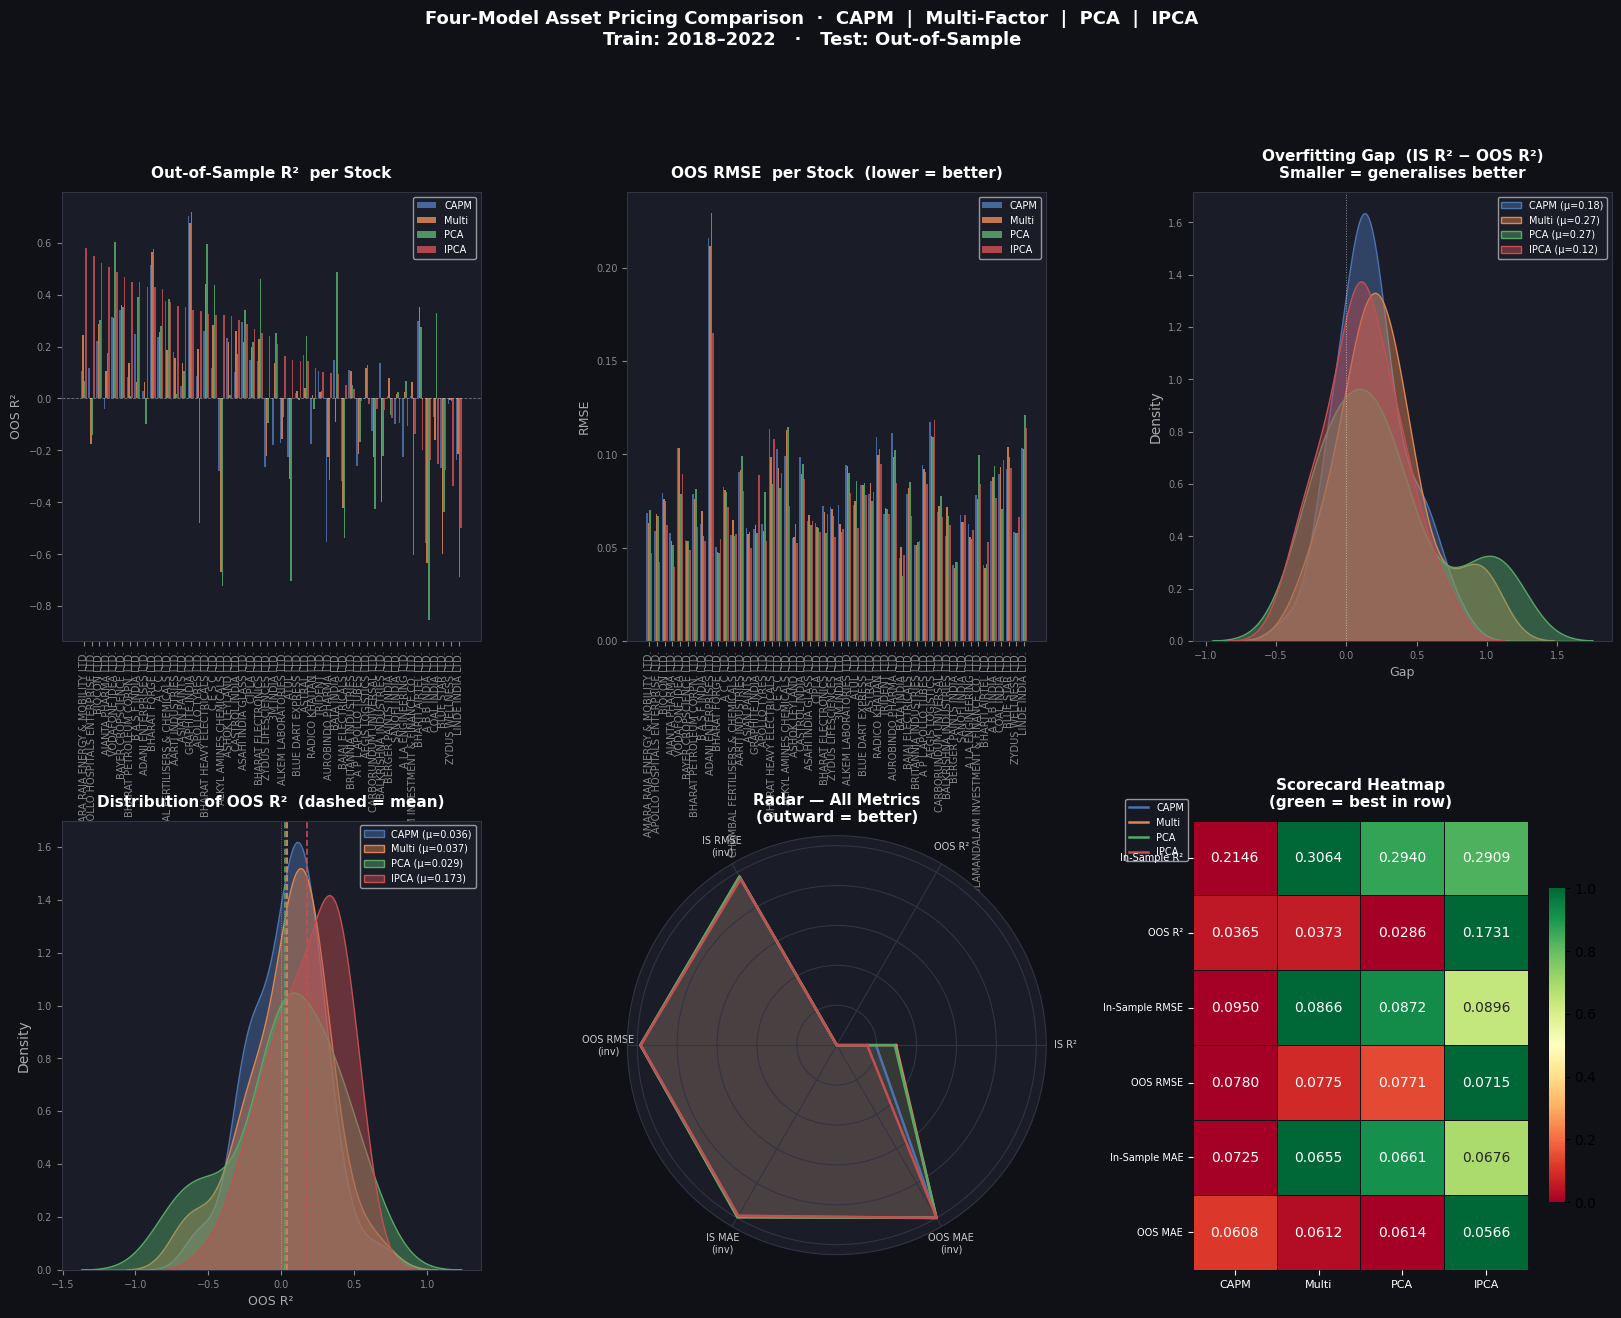


Done — figure saved to four_model_comparison.png


/tmp/ipykernel_54195/950697475.py:620: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


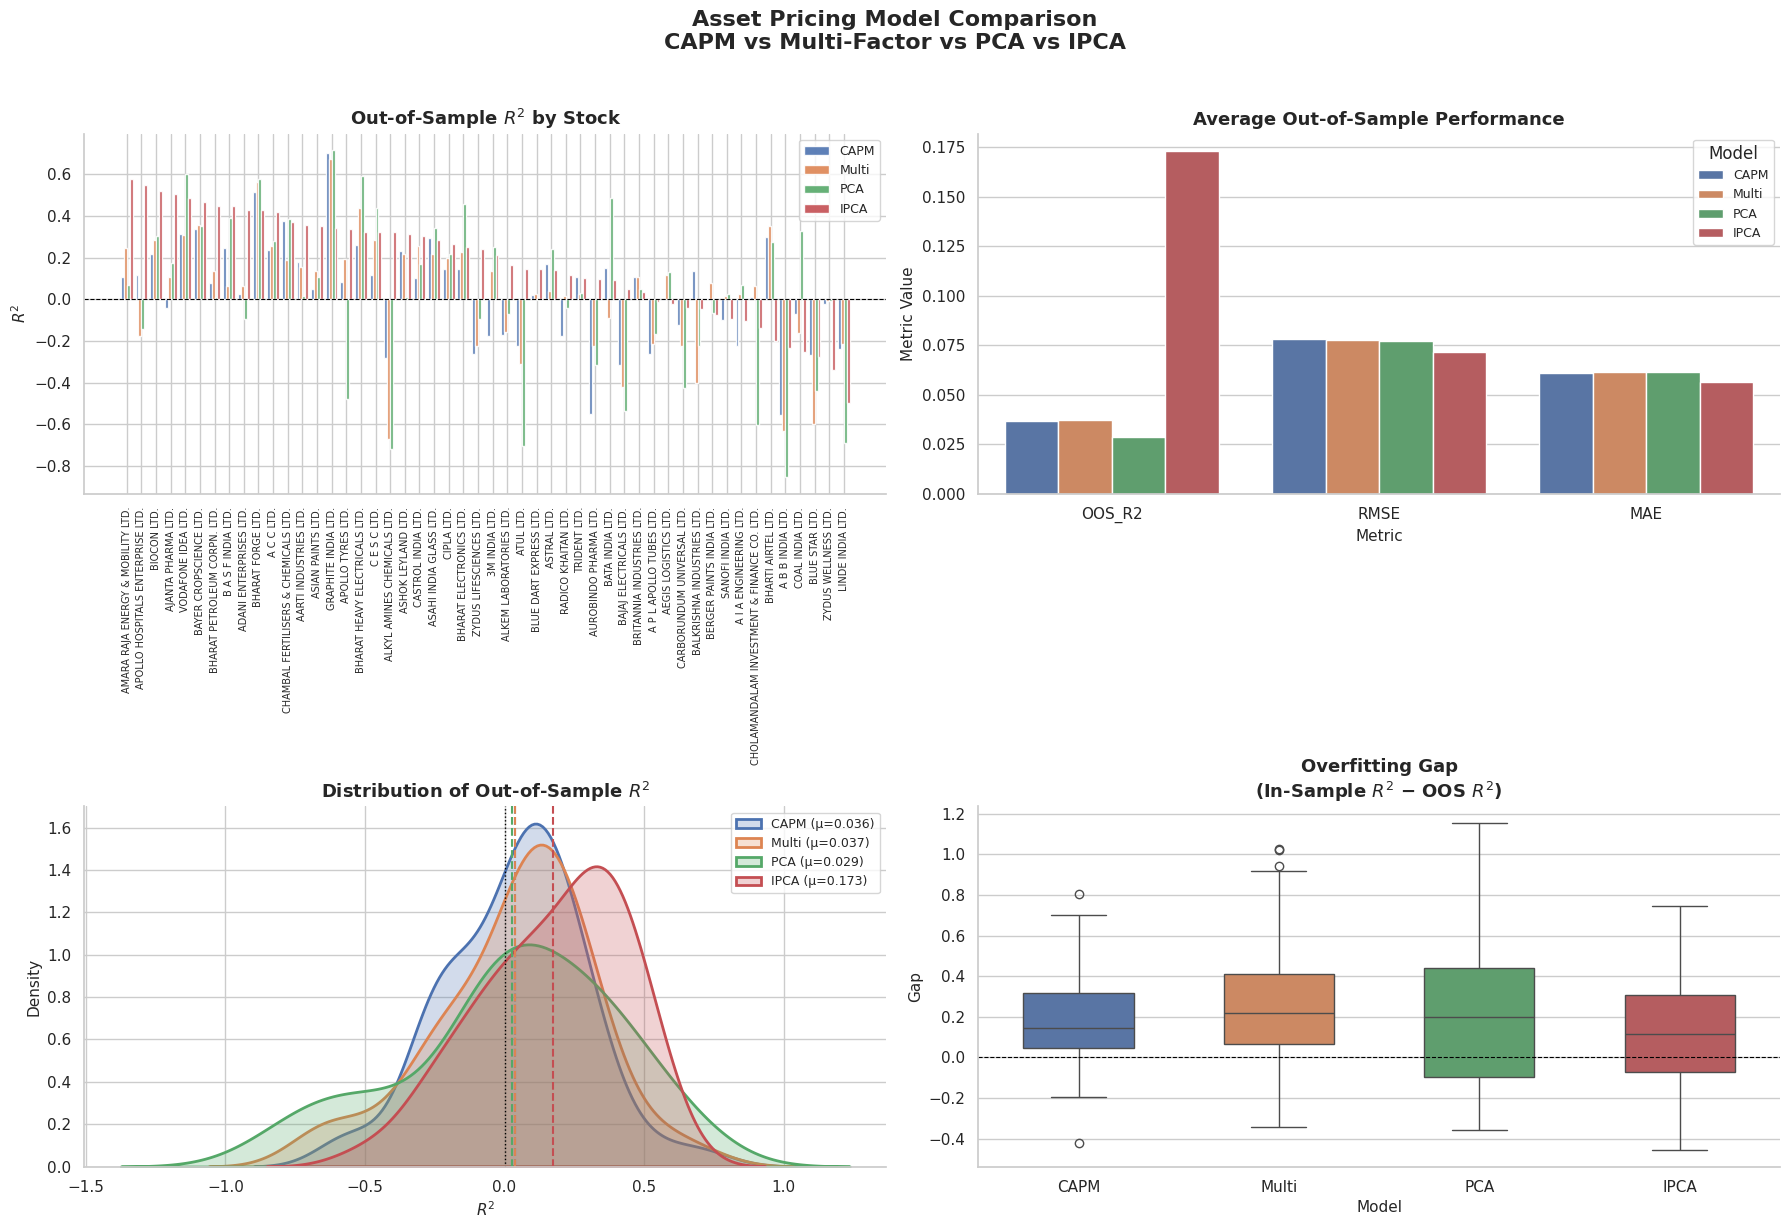


Clean figure saved as: clean_model_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ══════════════════════════════════════════════════════════════════
# 1. LOAD & PREPARE
# ══════════════════════════════════════════════════════════════════
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')

RF = 0.0045
df['Y']      = df['Stock_Return']  - RF
df['Mkt_RF'] = df['Market_Return'] - RF

char_cols = ['SMB', 'HML', 'WML', 'Size', 'BM', 'Momentum']

train_df = df[df['Year'].between(2018, 2022)].copy()
test_df  = df[df['Year'] > 2022].copy()

# ─── FIX: sort BOTH frames by Month + Co_Name before anything else ───────────
# This guarantees that when we assign .predict_insample() / .predict_oos()
# back as a column, the positional array lines up with the correct row.
train_df = train_df.sort_values(['Month', 'Co_Name']).reset_index(drop=True)
test_df  = test_df.sort_values(['Month',  'Co_Name']).reset_index(drop=True)

print(f"Training : {len(train_df)} rows  ({train_df['Year'].min()}–{train_df['Year'].max()})")
print(f"Testing  : {len(test_df)} rows   ({test_df['Year'].min()}–{test_df['Year'].max()})")


# ══════════════════════════════════════════════════════════════════
# 2. STATIC PCA  (fit on train only)
# ══════════════════════════════════════════════════════════════════
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[char_cols])
X_test_scaled  = scaler.transform(test_df[char_cols])

pca = PCA(n_components=3)
pca.fit(X_train_scaled)

train_df[['PC1', 'PC2', 'PC3']] = pca.transform(X_train_scaled)
test_df [['PC1', 'PC2', 'PC3']] = pca.transform(X_test_scaled)


# ══════════════════════════════════════════════════════════════════
# 3. IPCA — Kelly, Pruitt & Su (2019)
#
#    Key idea : β_{i,t} = Γ · z_{i,t}   (betas are linear in characteristics)
#    Model    : r_{i,t} = z_{i,t}' Γ' f_t  + ε_{i,t}
#
#    Estimation via Alternating Least Squares (ALS) with ridge regularisation
#    (alpha) to keep factor and Γ estimates stable:
#      Given Γ  → ridge-regress r on (ZΓ) each period  → {f_t}
#      Given {f_t} → ridge-regress r on (z ⊗ f) pooled → Γ
#    Repeat until convergence.
#
#    Changes vs original code
#    ─────────────────────────
#    • Ridge penalty (alpha) added to both solve steps  ← from v2
#    • Factor clipping kept to prevent numerical explosions
#    • predict_insample / predict_oos use the SAME df that was sorted before
#      fitting, so the returned numpy array is positionally aligned with
#      train_df / test_df rows.  The assignment
#          train_df['IPCA_pred'] = ipca.predict_insample(train_df)
#      is therefore safe.
# ══════════════════════════════════════════════════════════════════

class IPCA:
    """
    Instrumented PCA following Kelly, Pruitt & Su (2019).

    Parameters
    ----------
    K        : int   — number of latent factors
    alpha    : float — ridge penalty (stabilises small cross-sections)
    max_iter : int   — ALS iterations
    tol      : float — convergence threshold (Frobenius norm ΔΓ)
    """

    def __init__(self, K=3, alpha=1e-2, max_iter=200, tol=1e-6):
        self.K        = K
        self.alpha    = alpha
        self.max_iter = max_iter
        self.tol      = tol
        self.Gamma_   = None
        self.factors_ = None
        self._scaler  = None
        self._char_cols = None

    # ── internal helpers ─────────────────────────────────────────

    def _ridge(self, X, y):
        """Ridge regression: (X'X + αI)^{-1} X'y."""
        return np.linalg.solve(
            X.T @ X + self.alpha * np.eye(X.shape[1]),
            X.T @ y
        )

    @staticmethod
    def _normalise(M):
        """QR normalisation so columns of Γ are orthonormal."""
        Q, _ = np.linalg.qr(M)
        signs = np.sign(Q[np.argmax(np.abs(Q), axis=0), np.arange(Q.shape[1])])
        return Q * signs

    def _z(self, df):
        """Standardise characteristics using the fitted scaler."""
        return self._scaler.transform(df[self._char_cols])

    def _solve_factors(self, data_by_period, Gamma):
        factors = {}
        for t, grp in data_by_period:
            Z   = self._z(grp)          # (N_t, L)
            r   = grp['Y'].values
            ZG  = Z @ Gamma             # (N_t, K)  — time-varying betas
            ft  = self._ridge(ZG, r)
            factors[t] = np.clip(ft, -10, 10)
        return factors

    def _solve_gamma(self, data_by_period, factors):
        X_rows, y_rows = [], []
        for t, grp in data_by_period:
            Z  = self._z(grp)
            r  = grp['Y'].values
            ft = factors[t]
            # Kronecker rows: z_{i,t} ⊗ f_t  →  shape (N_t, K·L)
            kron = np.einsum('ij,k->ijk', Z, ft).reshape(len(Z), -1)
            X_rows.append(kron)
            y_rows.append(r)
        X_pool = np.vstack(X_rows)
        y_pool = np.concatenate(y_rows)
        gamma_vec = self._ridge(X_pool, y_pool)
        L = len(self._char_cols)
        return gamma_vec.reshape(L, self.K)     # (L, K)

    # ── public API ───────────────────────────────────────────────

    def fit(self, train_df, char_cols, period_col='Month'):
        self._char_cols  = char_cols
        self._period_col = period_col

        # Fit scaler on training characteristics
        self._scaler = StandardScaler()
        self._scaler.fit(train_df[char_cols])

        L = len(char_cols)

        # Warm-start Γ from static PCA on scaled chars
        Xs = self._scaler.transform(train_df[char_cols])
        Gamma = PCA(n_components=self.K).fit(Xs).components_.T    # (L, K)

        data_by_period = list(train_df.groupby(period_col))

        for iteration in range(self.max_iter):
            factors   = self._solve_factors(data_by_period, Gamma)
            Gamma_new = self._solve_gamma(data_by_period, factors)
            Gamma_new = self._normalise(Gamma_new)

            delta = np.linalg.norm(Gamma_new - Gamma, 'fro')
            Gamma = Gamma_new
            if delta < self.tol:
                print(f"  IPCA converged at iteration {iteration+1}  (ΔΓ = {delta:.2e})")
                break
        else:
            print(f"  IPCA reached max_iter={self.max_iter}  (ΔΓ = {delta:.2e})")

        self.Gamma_   = Gamma
        self.factors_ = factors
        return self

    def predict_insample(self, df, period_col='Month'):
        """
        In-sample: use stored f_t (estimated during fit).
        IMPORTANT: df must be sorted by [Month, Co_Name] — same order as fit().
        The returned array is positionally aligned with df.
        """
        preds = []
        for t, grp in df.groupby(period_col):
            Z  = self._z(grp)
            ft = self.factors_.get(t, np.zeros(self.K))
            preds.append(Z @ self.Gamma_ @ ft)
        return np.concatenate(preds)

    def predict_oos(self, df, period_col='Month'):
        """
        OOS: re-estimate f_t from test returns using trained Γ,
        then predict.  Mimics realistic forecasting.
        df must also be sorted by [Month, Co_Name].
        """
        preds = []
        for t, grp in df.groupby(period_col):
            Z  = self._z(grp)
            r  = grp['Y'].values
            ZG = Z @ self.Gamma_
            ft = self._ridge(ZG, r)
            preds.append(ZG @ ft)
        return np.concatenate(preds)

    def gamma_table(self):
        return pd.DataFrame(
            self.Gamma_,
            index   = self._char_cols,
            columns = [f'Factor{k+1}' for k in range(self.K)]
        )


# ── Fit IPCA ─────────────────────────────────────────────────────
print("\nFitting IPCA...")
ipca = IPCA(K=3, alpha=1e-2, max_iter=200, tol=1e-6)
ipca.fit(train_df, char_cols, period_col='Month')

print("\nIPCA Γ (characteristic loadings onto latent factors):")
print(ipca.gamma_table().round(4))

# ─── FIX: assign predictions directly to the sorted train_df / test_df ───────
# Because both frames are sorted by [Month, Co_Name] (step 1) and
# groupby('Month') preserves that sort order, the concatenated array
# is guaranteed to be positionally aligned with train_df / test_df rows.
train_df['IPCA_pred'] = ipca.predict_insample(train_df, 'Month')
test_df ['IPCA_pred'] = ipca.predict_oos(test_df,  'Month')


# ══════════════════════════════════════════════════════════════════
# 4. PER-STOCK EVALUATION — all four models, IS + OOS
# ══════════════════════════════════════════════════════════════════

def oos_metrics(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    return r2, rmse, mae


stocks  = train_df['Co_Name'].unique()
results = []

for stock in stocks:
    # ── Slice from the SAME sorted frames used for IPCA ──────────
    tr = train_df[train_df['Co_Name'] == stock]
    te = test_df [test_df ['Co_Name'] == stock]

    if len(te) == 0:
        continue

    # Actual returns (from the same sorted frame — no mismatch)
    y_train = tr['Y'].values
    y_test  = te['Y'].values

    row = {'Stock': stock}

    # ── Static models: CAPM, Multi-Factor, PCA ───────────────────
    model_specs = {
        'CAPM'  : ['Mkt_RF'],
        'Multi' : ['Mkt_RF', 'SMB', 'HML', 'WML'],
        'PCA'   : ['Mkt_RF', 'PC1', 'PC2', 'PC3'],
    }

    for name, cols in model_specs.items():
        fitted = sm.OLS(tr['Y'], sm.add_constant(tr[cols])).fit()
        y_is   = fitted.fittedvalues.values
        y_oos  = fitted.predict(sm.add_constant(te[cols])).values

        row[f'{name}_IS_R2']   = fitted.rsquared_adj
        row[f'{name}_IS_RMSE'] = np.sqrt(mean_squared_error(y_train, y_is))
        row[f'{name}_IS_MAE']  = np.mean(np.abs(y_train - y_is))

        row[f'{name}_OOS_R2'], row[f'{name}_RMSE'], row[f'{name}_MAE'] = \
            oos_metrics(y_test, y_oos)

    # ── IPCA ──────────────────────────────────────────────────────
    y_ipca_is  = tr['IPCA_pred'].values   # FIX: same frame as y_train
    y_ipca_oos = te['IPCA_pred'].values

    row['IPCA_IS_R2']  = 1 - np.sum((y_train - y_ipca_is)**2) / \
                             np.sum((y_train - y_train.mean())**2)
    row['IPCA_IS_RMSE'] = np.sqrt(mean_squared_error(y_train, y_ipca_is))
    row['IPCA_IS_MAE']  = np.mean(np.abs(y_train - y_ipca_is))

    row['IPCA_OOS_R2'], row['IPCA_RMSE'], row['IPCA_MAE'] = \
        oos_metrics(y_test, y_ipca_oos)

    results.append(row)

res = pd.DataFrame(results)


# ══════════════════════════════════════════════════════════════════
# 5. SUMMARY SCORECARD
# ══════════════════════════════════════════════════════════════════
model_names  = ['CAPM', 'Multi', 'PCA', 'IPCA']
metric_pairs = [
    ('IS_R2',   'In-Sample R²',   'max'),
    ('OOS_R2',  'OOS R²',         'max'),
    ('IS_RMSE', 'In-Sample RMSE', 'min'),
    ('RMSE',    'OOS RMSE',       'min'),
    ('IS_MAE',  'In-Sample MAE',  'min'),
    ('MAE',     'OOS MAE',        'min'),
]

print("\n" + "═"*72)
print("  FULL MODEL SCORECARD  (mean across all stocks)")
print("═"*72)
print(f"{'Metric':<20}" + "".join(f"{m:>12}" for m in model_names) + "  ← WINNER")
print("─"*72)

scoreboard = {m: 0 for m in model_names}
for col, label, direction in metric_pairs:
    means  = {m: res[f'{m}_{col}'].mean() for m in model_names}
    winner = (max if direction == 'max' else min)(means, key=means.get)
    scoreboard[winner] += 1
    vals = "".join(f"{means[m]:>12.4f}" for m in model_names)
    print(f"{label:<20}{vals}  ✓ {winner}")

print("─"*72)
print(f"{'Points (6 total)':<20}" + "".join(f"{scoreboard[m]:>12}" for m in model_names))
overall_winner = max(scoreboard, key=scoreboard.get)
print(f"\n  ★  BEST OVERALL MODEL: {overall_winner}  ({scoreboard[overall_winner]}/6 metrics won)")
print("═"*72)


# ══════════════════════════════════════════════════════════════════
# 6. VISUALISATION — 6-panel dark dashboard
# ══════════════════════════════════════════════════════════════════
palette = {
    'CAPM' : '#4C72B0',
    'Multi': '#DD8452',
    'PCA'  : '#55A868',
    'IPCA' : '#C44E52',
}

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0F1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

title_kw = dict(color='white', fontsize=11, fontweight='bold', pad=10)
label_kw = dict(color='#AAAAAA', fontsize=9)
tick_kw  = dict(colors='#888888', labelsize=7)

def style_ax(ax):
    ax.set_facecolor('#1A1D27')
    ax.tick_params(axis='both', **tick_kw)
    ax.spines[['top', 'right', 'left', 'bottom']].set_color('#333344')
    ax.xaxis.label.set_color('#AAAAAA')
    ax.yaxis.label.set_color('#AAAAAA')

r_s = res.sort_values('IPCA_OOS_R2', ascending=False)
x   = np.arange(len(r_s))
w   = 0.20

# ── Panel 1: OOS R² per stock ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for i, m in enumerate(model_names):
    ax1.bar(x + (i - 1.5) * w, r_s[f'{m}_OOS_R2'], w,
            label=m, color=palette[m], alpha=0.88)
ax1.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax1.set_xticks(x)
ax1.set_xticklabels(r_s['Stock'], rotation=90, fontsize=5)
ax1.set_title('Out-of-Sample R²  per Stock', **title_kw)
ax1.set_ylabel('OOS R²', **label_kw)
ax1.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.7)
style_ax(ax1)

# ── Panel 2: OOS RMSE per stock ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for i, m in enumerate(model_names):
    ax2.bar(x + (i - 1.5) * w, r_s[f'{m}_RMSE'], w,
            label=m, color=palette[m], alpha=0.88)
ax2.set_xticks(x)
ax2.set_xticklabels(r_s['Stock'], rotation=90, fontsize=5)
ax2.set_title('OOS RMSE  per Stock  (lower = better)', **title_kw)
ax2.set_ylabel('RMSE', **label_kw)
ax2.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.7)
style_ax(ax2)

# ── Panel 3: Overfitting gap  IS R² − OOS R² ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for m in model_names:
    gap = res[f'{m}_IS_R2'] - res[f'{m}_OOS_R2']
    sns.kdeplot(gap, fill=True, label=f'{m} (μ={gap.mean():.2f})',
                color=palette[m], ax=ax3, alpha=0.45)
ax3.axvline(0, color='white', linewidth=0.7, linestyle=':', alpha=0.5)
ax3.set_title('Overfitting Gap  (IS R² − OOS R²)\nSmaller = generalises better', **title_kw)
ax3.set_xlabel('Gap', **label_kw)
ax3.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.7)
style_ax(ax3)

# ── Panel 4: KDE of OOS R² ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for m in model_names:
    col = res[f'{m}_OOS_R2']
    sns.kdeplot(col, fill=True, label=f'{m} (μ={col.mean():.3f})',
                color=palette[m], ax=ax4, alpha=0.45)
    ax4.axvline(col.mean(), color=palette[m], linestyle='--', linewidth=1.2)
ax4.axvline(0, color='white', linewidth=0.6, linestyle=':', alpha=0.4)
ax4.set_title('Distribution of OOS R²  (dashed = mean)', **title_kw)
ax4.set_xlabel('OOS R²', **label_kw)
ax4.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.7)
style_ax(ax4)

# ── Panel 5: Radar / Spider chart ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1], polar=True)
ax5.set_facecolor('#1A1D27')

radar_labels = ['IS R²', 'OOS R²', 'IS RMSE\n(inv)', 'OOS RMSE\n(inv)',
                'IS MAE\n(inv)', 'OOS MAE\n(inv)']
N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def normalise_radar(vals, invert_idx):
    out = np.array(vals, dtype=float)
    for i in invert_idx:
        out[i] = 1 / (1 + out[i])
    mn, mx = out.min(), out.max()
    return (out - mn) / (mx - mn + 1e-9)

raw = {
    m: [
        res[f'{m}_IS_R2'].mean(),
        res[f'{m}_OOS_R2'].mean(),
        res[f'{m}_IS_RMSE'].mean(),
        res[f'{m}_RMSE'].mean(),
        res[f'{m}_IS_MAE'].mean(),
        res[f'{m}_MAE'].mean(),
    ]
    for m in model_names
}

for m in model_names:
    v = normalise_radar(raw[m], invert_idx=[2, 3, 4, 5]).tolist()
    v += v[:1]
    ax5.plot(angles, v, color=palette[m], linewidth=1.8, label=m)
    ax5.fill(angles, v, color=palette[m], alpha=0.12)

ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(radar_labels, size=7, color='#CCCCCC')
ax5.set_yticklabels([])
ax5.set_title('Radar — All Metrics\n(outward = better)', **title_kw)
ax5.grid(color='#333344')
ax5.spines['polar'].set_color('#333344')
ax5.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1),
           fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.7)

# ── Panel 6: Scorecard heatmap ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
score_data = pd.DataFrame(
    {m: [res[f'{m}_{col}'].mean() for col, *_ in metric_pairs] for m in model_names},
    index=[lbl for _, lbl, _ in metric_pairs]
)

score_norm = score_data.copy()
for col, lbl, direction in metric_pairs:
    row_vals = score_data.loc[lbl]
    mn, mx   = row_vals.min(), row_vals.max()
    if direction == 'max':
        score_norm.loc[lbl] = (row_vals - mn) / (mx - mn + 1e-9)
    else:
        score_norm.loc[lbl] = 1 - (row_vals - mn) / (mx - mn + 1e-9)

sns.heatmap(
    score_norm.astype(float),
    annot=score_data.round(4), fmt='.4f',
    cmap='RdYlGn', ax=ax6,
    linewidths=0.5, linecolor='#0F1117',
    cbar_kws={'shrink': 0.7}
)
ax6.set_title('Scorecard Heatmap\n(green = best in row)', **title_kw)
ax6.tick_params(axis='x', colors='white', labelsize=8)
ax6.tick_params(axis='y', colors='white', labelsize=7, rotation=0)

fig.suptitle(
    'Four-Model Asset Pricing Comparison  ·  CAPM  |  Multi-Factor  |  PCA  |  IPCA\n'
    'Train: 2018–2022   ·   Test: Out-of-Sample',
    color='white', fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('four_model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("\nDone — figure saved to four_model_comparison.png")
#######################

# ══════════════════════════════════════════════════════════════════
# 6. CLEAN PROFESSIONAL VISUALISATION
#    White background • publication style • more interpretable
# ══════════════════════════════════════════════════════════════════

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.titlesize': 16
})

palette = {
    'CAPM' : '#4C72B0',
    'Multi': '#DD8452',
    'PCA'  : '#55A868',
    'IPCA' : '#C44E52',
}

# Sort by IPCA OOS performance
r_s = res.sort_values('IPCA_OOS_R2', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('white')

# ================================================================
# PANEL 1 — OOS R² COMPARISON (clean grouped bars)
# ================================================================
ax = axes[0, 0]

x = np.arange(len(r_s))
w = 0.2

for i, m in enumerate(model_names):
    ax.bar(
        x + (i - 1.5)*w,
        r_s[f'{m}_OOS_R2'],
        width=w,
        label=m,
        color=palette[m],
        alpha=0.9
    )

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(r_s['Stock'], rotation=90, fontsize=7)

ax.set_title('Out-of-Sample $R^2$ by Stock', fontweight='bold')
ax.set_ylabel('$R^2$')
ax.legend(frameon=True)

sns.despine(ax=ax)

# ================================================================
# PANEL 2 — MEAN PERFORMANCE COMPARISON
# ================================================================
ax = axes[0, 1]

summary_metrics = pd.DataFrame({
    'Model': model_names,
    'OOS_R2': [res[f'{m}_OOS_R2'].mean() for m in model_names],
    'RMSE':   [res[f'{m}_RMSE'].mean() for m in model_names],
    'MAE':    [res[f'{m}_MAE'].mean() for m in model_names]
})

summary_long = summary_metrics.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Value'
)

sns.barplot(
    data=summary_long,
    x='Metric',
    y='Value',
    hue='Model',
    palette=palette,
    ax=ax
)

ax.set_title('Average Out-of-Sample Performance', fontweight='bold')
ax.set_ylabel('Metric Value')

sns.despine(ax=ax)

# ================================================================
# PANEL 3 — DISTRIBUTION OF OOS R²
# ================================================================
ax = axes[1, 0]

for m in model_names:
    sns.kdeplot(
        res[f'{m}_OOS_R2'],
        fill=True,
        linewidth=2,
        alpha=0.25,
        label=f'{m} (μ={res[f"{m}_OOS_R2"].mean():.3f})',
        color=palette[m],
        ax=ax
    )

    ax.axvline(
        res[f'{m}_OOS_R2'].mean(),
        color=palette[m],
        linestyle='--',
        linewidth=1.5
    )

ax.axvline(0, color='black', linestyle=':', linewidth=1)

ax.set_title('Distribution of Out-of-Sample $R^2$', fontweight='bold')
ax.set_xlabel('$R^2$')
ax.legend()

sns.despine(ax=ax)

# ================================================================
# PANEL 4 — OVERFITTING GAP
# ================================================================
ax = axes[1, 1]

gap_df = pd.DataFrame()

for m in model_names:
    gap_df[m] = res[f'{m}_IS_R2'] - res[f'{m}_OOS_R2']

gap_long = gap_df.melt(var_name='Model', value_name='Gap')

sns.boxplot(
    data=gap_long,
    x='Model',
    y='Gap',
    palette=palette,
    width=0.55,
    ax=ax
)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_title('Overfitting Gap\n(In-Sample $R^2$ − OOS $R^2$)', fontweight='bold')
ax.set_ylabel('Gap')

sns.despine(ax=ax)

# ================================================================
# GLOBAL TITLE
# ================================================================
fig.suptitle(
    'Asset Pricing Model Comparison\nCAPM vs Multi-Factor vs PCA vs IPCA',
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'clean_model_comparison.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\nClean figure saved as: clean_model_comparison.png")